**Install & Import Libraries**

In [ ]:
!pip install tensorflow gradio seaborn plotly scikit-learn --quiet

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# TensorFlow ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print('All Libraries Imported Successfully')

All Libraries Imported Successfully


In [ ]:
import os

if os.path.exists("Symptom_to_Disease.csv"):
    os.remove("Symptom_to_Disease.csv")

if os.path.exists("Disease_to_Medicine.csv"):
    os.remove("Disease_to_Medicine.csv")

print("Old CSV Files Deleted")

Old CSV Files Deleted


**Upload Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

# symptoms_data = pd.read_csv('/content/drive/MyDrive/AI MEDICAL AGENT DATASETS/dataset1.csv')

# medicine_data = pd.read_csv('/content/drive/MyDrive/AI MEDICAL AGENT DATASETS/Disease_to_Medicine.csv')

Saving description.csv to description.csv
Saving Diseases_and_Symptoms_dataset.csv to Diseases_and_Symptoms_dataset.csv


**Load & DISPLAY DATASET**

In [ ]:
symptom_df = pd.read_csv('Diseases_and_Symptoms_dataset.csv')
medicine_df = pd.read_csv('description.csv')

print('Symptom Dataset Shape:', symptom_df.shape)
print('Medicine Dataset Shape:', medicine_df.shape)

Symptom Dataset Shape: (96088, 231)
Medicine Dataset Shape: (100, 9)


In [ ]:
print('\nsymptoms_data')
display(symptom_df.head())

print('\nmedicine_data')
display(medicine_df.head())


symptoms_data


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0



medicine_data


,Disease,Description,Diet,Precaution_1,Precaution_2,Precaution_3,Precaution_4,Workouts,Medication
0,Panic disorder,Panic disorder is a mental health condition ma...,"['Magnesium-rich foods (spinach, pumpkin seeds...",Practice deep breathing,Avoid caffeine,Follow therapy plan,Seek support from loved ones,"[""Deep breathing exercises: Calm your mind by ...","['SSRIs (e.g., Sertraline, Fluoxetine)', 'Benz..."
1,Vaginitis,Vaginitis is inflammation of the vaginal tissu...,"['Probiotics (yogurt, kefir, sauerkraut)', 'Lo...",Wear breathable cotton underwear,Avoid douching,Maintain genital hygiene,Avoid scented hygiene products,"[""Pelvic floor exercises: Strengthen pelvic mu...","['Metronidazole', 'Clindamycin', 'Fluconazole'..."
2,Problem during pregnancy,Problems during pregnancy refer to medical com...,"['Prenatal vitamins (consult doctor)', 'Iron-r...",Attend regular prenatal visits,Avoid alcohol and smoking,Eat a balanced diet,Get adequate rest,"[""Prenatal yoga: Gentle stretches safe for pre...","['Prenatal vitamins', 'Iron supplements', 'Ant..."
3,Acute pancreatitis,Acute pancreatitis is a sudden inflammation of...,"['Low-fat foods (boiled vegetables, lean chick...",Avoid alcohol,Eat a low-fat diet,Stay hydrated,Follow doctor's advice strictly,"[""Avoid heavy lifting: Prevent strain on pancr...","['IV fluids', 'Pain relievers (e.g., Morphine)..."
4,Asthma,Asthma is a chronic inflammatory disease of th...,"['Anti-inflammatory foods (blueberries, kale, ...",Avoid known triggers,Use inhaler as prescribed,Monitor peak flow,Keep emergency inhaler handy,"[""Breathing exercises: Improve lung function"",...","['Inhaled corticosteroids (e.g., Fluticasone)'..."


**Data Cleaning & Preprocessing**

In [ ]:
print(symptom_df.isnull().sum())
print(medicine_df.isnull().sum())

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
pain in gums                        0
diaper rash                         0
hesitancy                           0
back stiffness or tightness         0
low urine output                    0
Length: 231, dtype: int64
Disease         0
Description     0
Diet            0
Precaution_1    0
Precaution_2    0
Precaution_3    0
Precaution_4    0
Workouts        0
Medication      0
dtype: int64


In [ ]:
# Fill symptom columns with 0
for col in symptom_df.columns:

    if symptom_df[col].dtype != 'object':
        symptom_df[col] = symptom_df[col].fillna(0)

# Fill prognosis with mode
symptom_df['diseases'] = symptom_df['diseases'].fillna(
    symptom_df['diseases'].mode()[0]
)

# ----- MEDICINE DATASET -----

for col in medicine_df.columns:

    # Numerical columns
    if medicine_df[col].dtype != 'object':

        medicine_df[col] = medicine_df[col].fillna(
            medicine_df[col].median()
        )

    # Text columns
    else:

        medicine_df[col] = medicine_df[col].fillna(
            medicine_df[col].mode()[0]
        )

print("Null Values Handled Successfully")

Null Values Handled Successfully


In [ ]:
print(symptom_df.isnull().sum())
print(medicine_df.isnull().sum())

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
pain in gums                        0
diaper rash                         0
hesitancy                           0
back stiffness or tightness         0
low urine output                    0
Length: 231, dtype: int64
Disease         0
Description     0
Diet            0
Precaution_1    0
Precaution_2    0
Precaution_3    0
Precaution_4    0
Workouts        0
Medication      0
dtype: int64


In [ ]:
symptom_df.drop_duplicates(inplace=True)
medicine_df.drop_duplicates(inplace=True)

print('Duplicates Removed')

Duplicates Removed


In [ ]:
label_encoder = LabelEncoder()

symptom_df['diseases_encoded'] = label_encoder.fit_transform(symptom_df['diseases'])

print(label_encoder.classes_)

['actinic keratosis' 'acute bronchiolitis' 'acute bronchitis'
 'acute bronchospasm' 'acute kidney injury' 'acute pancreatitis'
 'acute sinusitis' 'allergy' 'angina' 'anxiety' 'appendicitis'
 'arthritis of the hip' 'asthma' 'benign prostatic hyperplasia (bph)'
 'brachial neuritis' 'bursitis' 'carpal tunnel syndrome' 'cholecystitis'
 'chronic back pain' 'chronic constipation'
 'chronic obstructive pulmonary disease (copd)' 'common cold'
 'complex regional pain syndrome' 'concussion' 'conjunctivitis'
 'conjunctivitis due to allergy' 'contact dermatitis' 'cornea infection'
 'croup' 'cystitis' 'degenerative disc disease' 'dental caries'
 'depression' 'developmental disability' 'diaper rash' 'diverticulitis'
 'drug reaction' 'ear drum damage' 'eczema' 'esophagitis'
 'eustachian tube dysfunction (ear disorder)'
 'fungal infection of the hair' 'gallstone' 'gastrointestinal hemorrhage'
 'gout' 'gum disease' 'heart attack' 'heart failure' 'hemorrhoids'
 'herniated disk' 'hiatal hernia' 'hypereme

In [ ]:
X = symptom_df.drop(['diseases', 'diseases_encoded'], axis=1)
y = symptom_df['diseases_encoded']

print(X.shape)
print(y.shape)

(96088, 230)
(96088,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoders dictionary
label_encoders = {}

# Encode all object/string columns
for col in X.columns:

    if X[col].dtype == 'object':

        le = LabelEncoder()

        X[col] = le.fit_transform(X[col].astype(str))

        label_encoders[col] = le

print("Categorical Columns Encoded Successfully")

Categorical Columns Encoded Successfully


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaling Completed')

Scaling Completed


**Data Visualization**

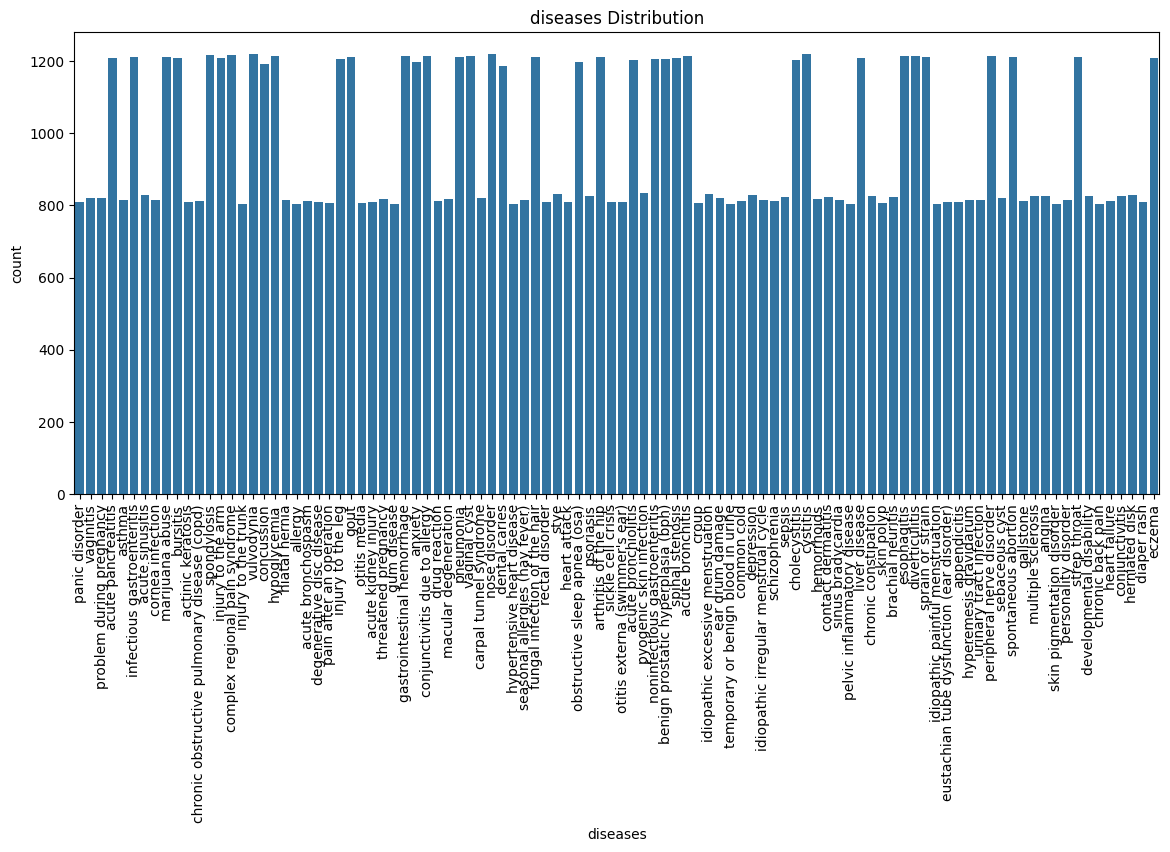

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(x=symptom_df['diseases'])
plt.xticks(rotation=90)
plt.title('diseases Distribution')
plt.show()

In [ ]:
# plt.figure(figsize=(9,9))
# sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
# plt.title('Feature Correlation Matrix')
# plt.show()

**FEATURE IMPORTANCE VISUALIZATION**

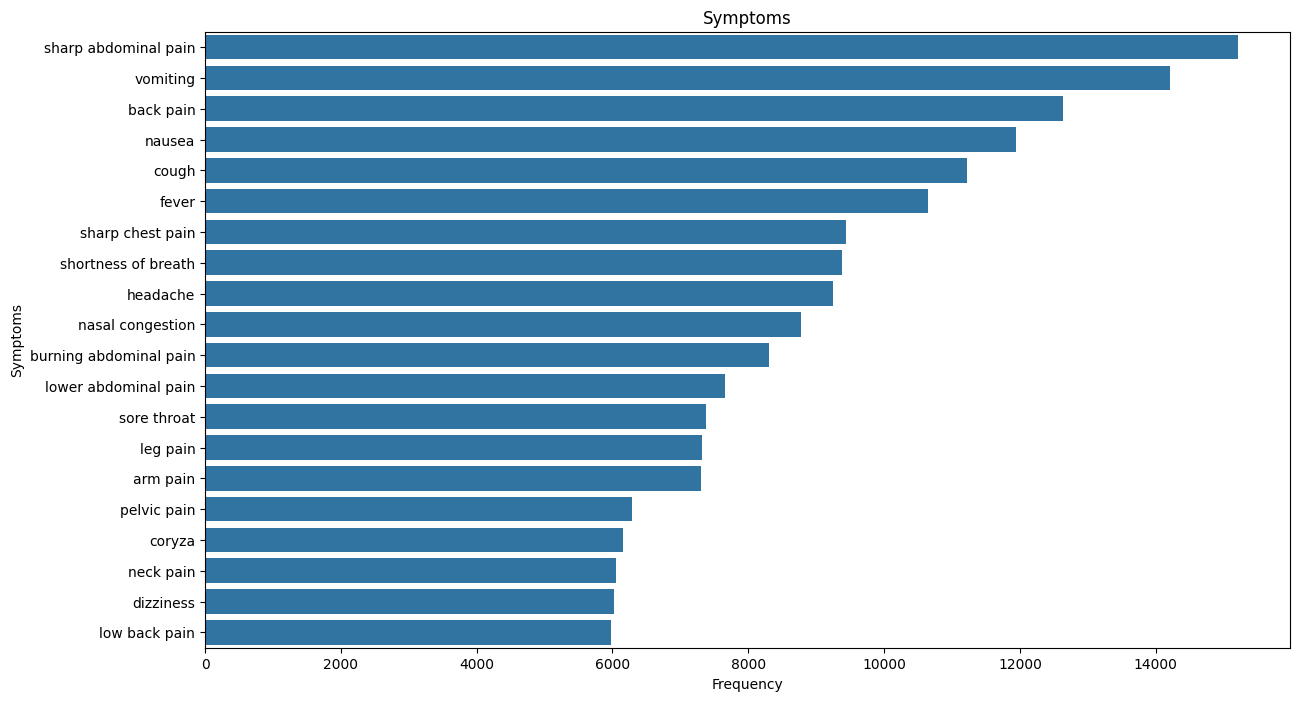

In [ ]:
feature_sum = X.sum().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=feature_sum.values[:20],
    y=feature_sum.index[:20]
)

plt.title('Symptoms')
plt.xlabel('Frequency')
plt.ylabel('Symptoms')

plt.show()

**Train Test Split**

In [ ]:
X = np.array(X_scaled)
y = np.array(y)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print('Training Shape:', X_train.shape)
print('Validation Shape:', X_val.shape)
print('Testing Shape:', X_test.shape)

Training Shape: (67261, 230)
Validation Shape: (14413, 230)
Testing Shape: (14414, 230)


In [ ]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

**ANN Model**


In [ ]:
ann_model = Sequential()

ann_model.add(Dense(512, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.2))

ann_model.add(Dense(256, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.2))

ann_model.add(Dense(128, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.2))

ann_model.add(Dense(64, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.1))

ann_model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(learning_rate=0.0005)

ann_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       118,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,092 (1.15 MB)

 Trainable params: 299,172 (1.14 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [ ]:
history = ann_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32,
    # callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7622 - loss: 1.0456 - val_accuracy: 0.8843 - val_loss: 0.2738
Epoch 2/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8632 - loss: 0.4061 - val_accuracy: 0.8894 - val_loss: 0.2601
Epoch 3/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8727 - loss: 0.3577 - val_accuracy: 0.8886 - val_loss: 0.2453
Epoch 4/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8773 - loss: 0.3357 - val_accuracy: 0.8895 - val_loss: 0.2496
Epoch 5/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8795 - loss: 0.3200 - val_accuracy: 0.8896 - val_loss: 0.2355
Epoch 6/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8833 - loss: 0.3067 - val_accuracy: 0.8887 - val_loss: 0.2448
Epoch 7/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8846 - loss: 0.2991 - val_accuracy: 0.8907 - val_loss: 0.2321
Epoch 8/10
2102/2102 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.8846 - loss: 0

**ANN Evaluation**

In [ ]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
ann_pred_prob = ann_model.predict(X_test)
ann_pred = np.argmax(ann_pred_prob, axis=1)

ann_accuracy = accuracy_score(y_test, ann_pred)
ann_precision = precision_score(y_test, ann_pred, average='weighted')
ann_recall = recall_score(y_test, ann_pred, average='weighted')
ann_f1 = f1_score(y_test, ann_pred, average='weighted')

print('ANN Accuracy:', ann_accuracy)
print('ANN Precision:', ann_precision)
print('ANN Recall:', ann_recall)
print('ANN F1 Score:', ann_f1)

451/451 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ANN Accuracy: 0.8878173997502429
ANN Precision: 0.8971410468183232
ANN Recall: 0.8878173997502429
ANN F1 Score: 0.8885175962392778


**ANN Evaluation Metrics Graph**

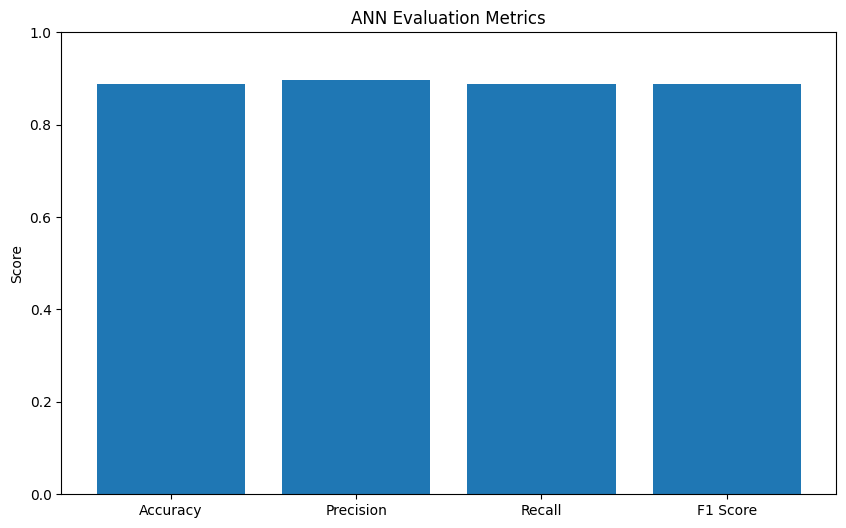

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [ann_accuracy, ann_precision, ann_recall, ann_f1]

plt.figure(figsize=(10,6))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.title('ANN Evaluation Metrics')
plt.ylabel('Score')
plt.show()

**Confusion Matrix**

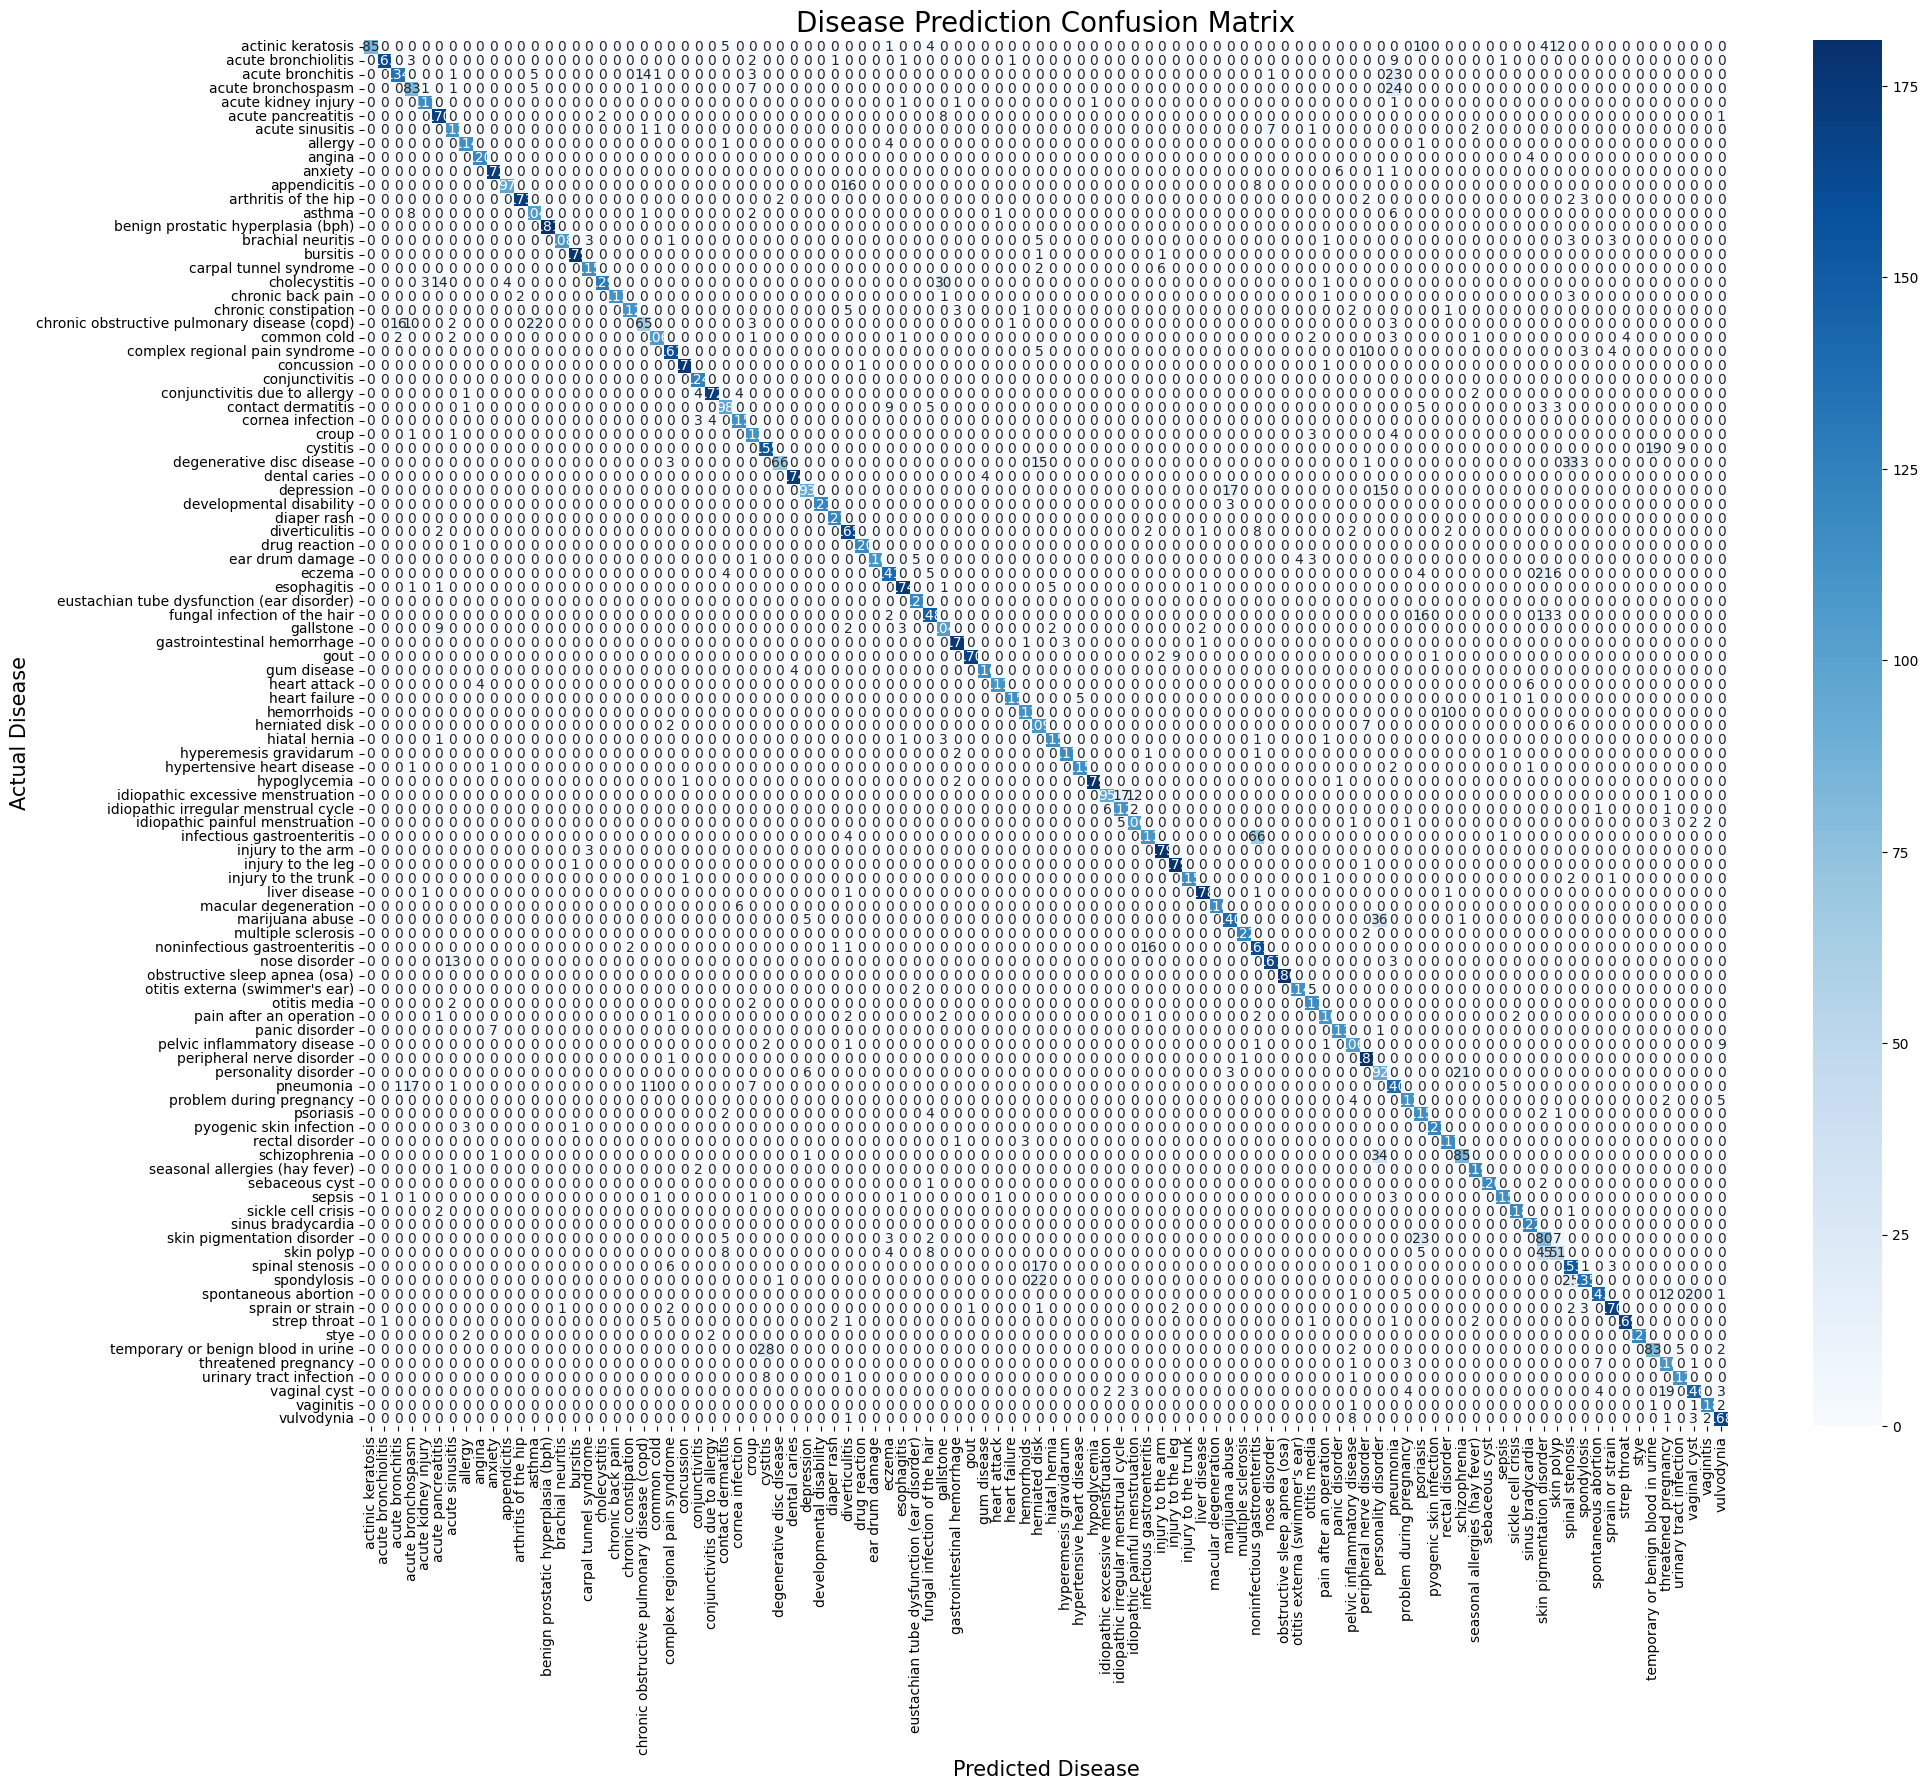

In [ ]:
cm = confusion_matrix(y_test, ann_pred)

class_names = label_encoder.classes_

plt.figure(figsize=(22,18))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Disease Prediction Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Disease', fontsize=15)
plt.ylabel('Actual Disease', fontsize=15)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

**Classification Report**

In [ ]:
print(classification_report(y_test, ann_pred))

              precision    recall  f1-score   support

           0       1.00      0.70      0.83       121
           1       0.99      0.90      0.94       181
           2       0.88      0.74      0.80       182
           3       0.66      0.68      0.67       122
           4       0.96      0.97      0.96       121
           5       0.85      0.94      0.89       181
           6       0.82      0.90      0.86       124
           7       0.93      0.95      0.94       120
           8       0.97      0.97      0.97       124
           9       0.95      0.96      0.95       180
          10       0.96      0.80      0.87       121
          11       0.99      0.95      0.97       182
          12       0.76      0.85      0.81       122
          13       1.00      1.00      1.00       181
          14       0.99      0.87      0.93       124
          15       0.99      0.99      0.99       181
          16       0.95      0.93      0.94       123
          17       0.98    

**ROC Curve**

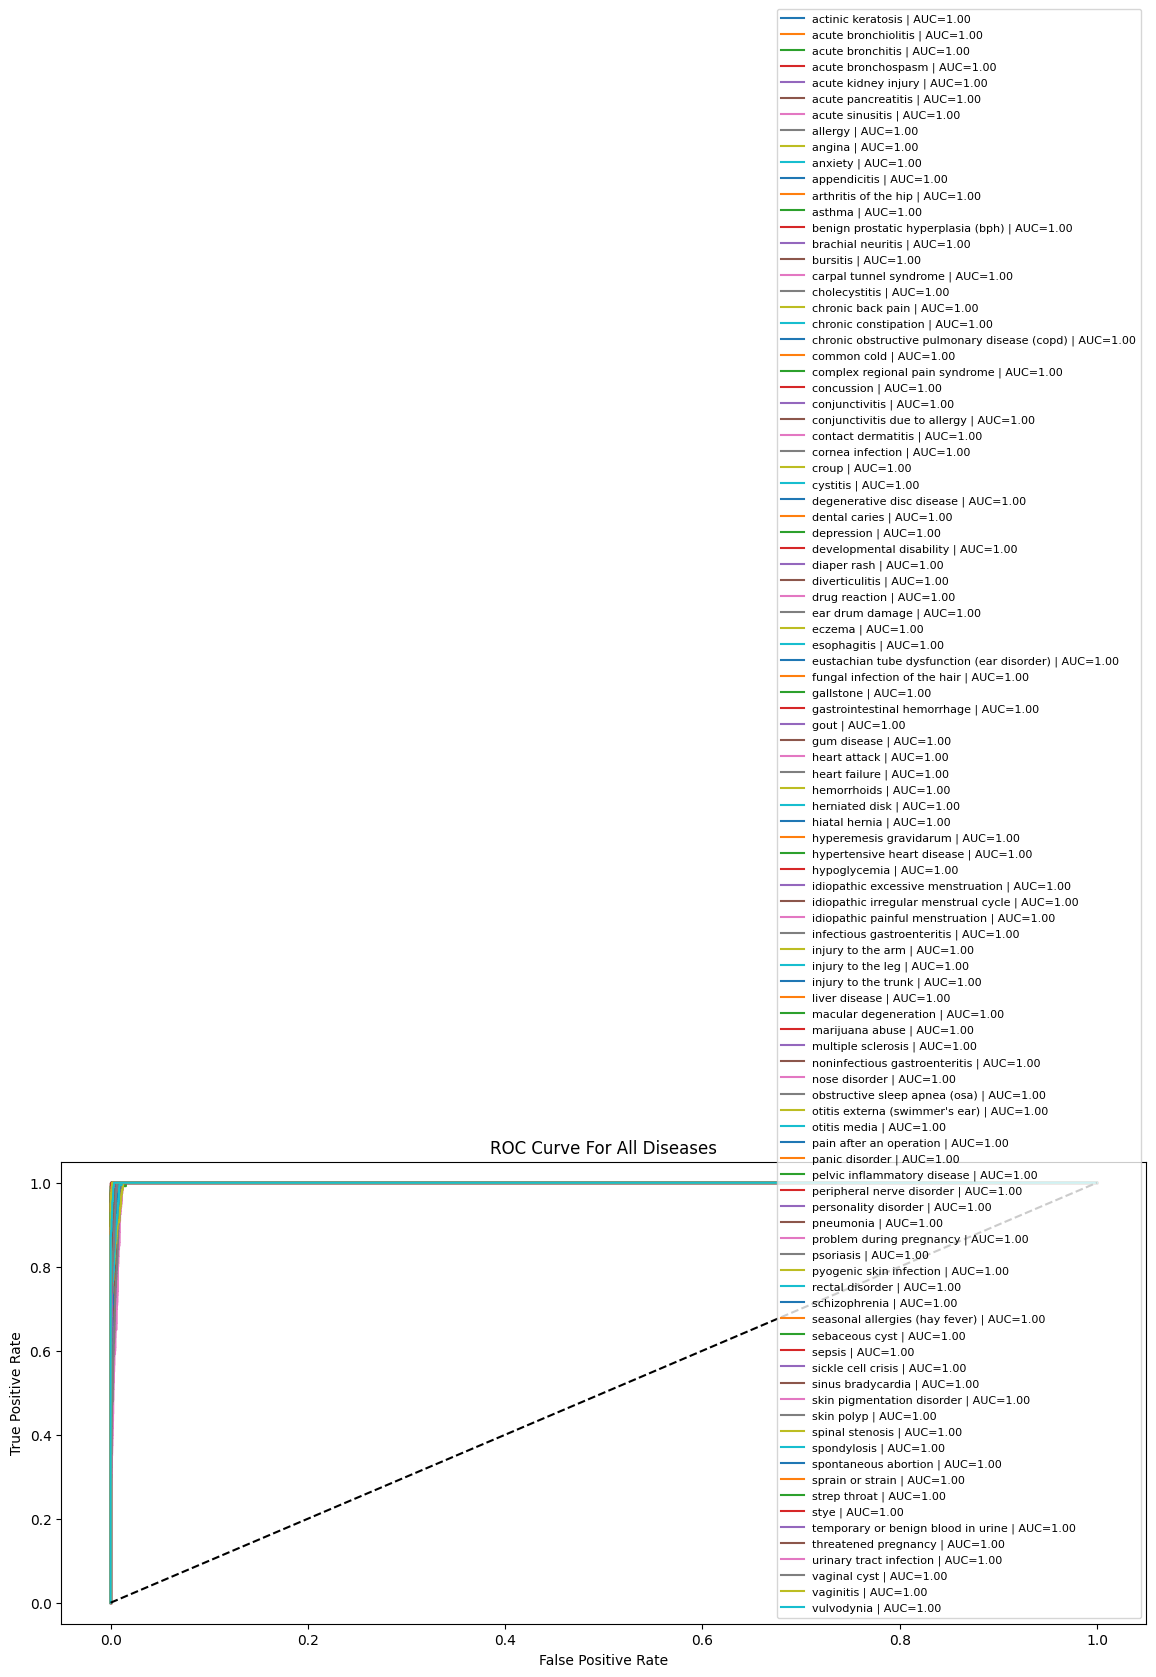

In [ ]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(14,6))

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        ann_pred_prob[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

    disease_name = label_encoder.inverse_transform([i])[0]

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{disease_name} | AUC={roc_auc[i]:.2f}'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve For All Diseases')

plt.legend(
    loc='lower right',
    fontsize=8
)

plt.show()

**Training Validation Accuracy Graph**

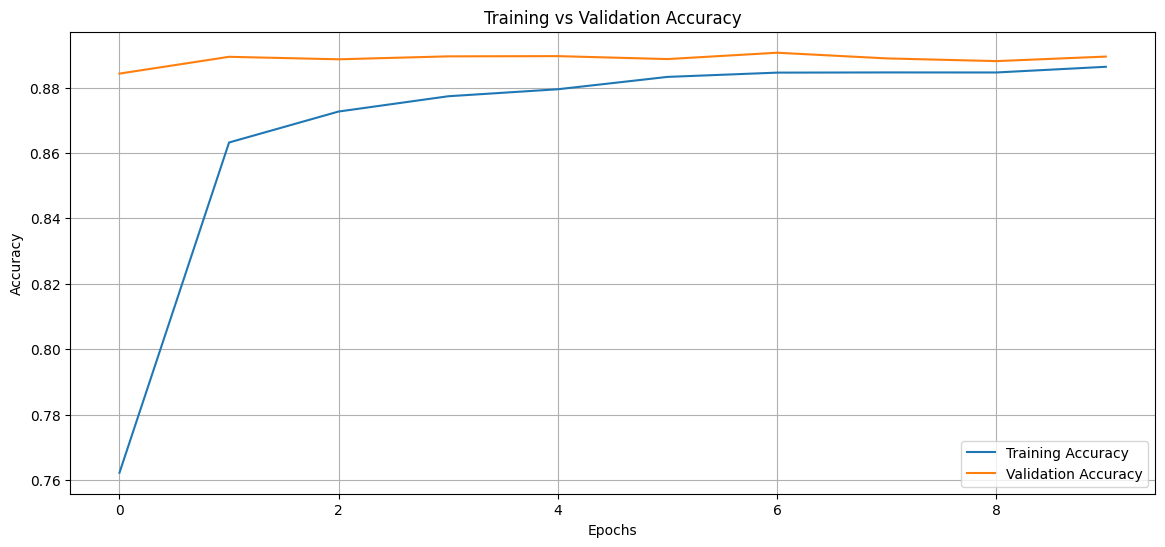

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

**Training Validation Loss Graph**

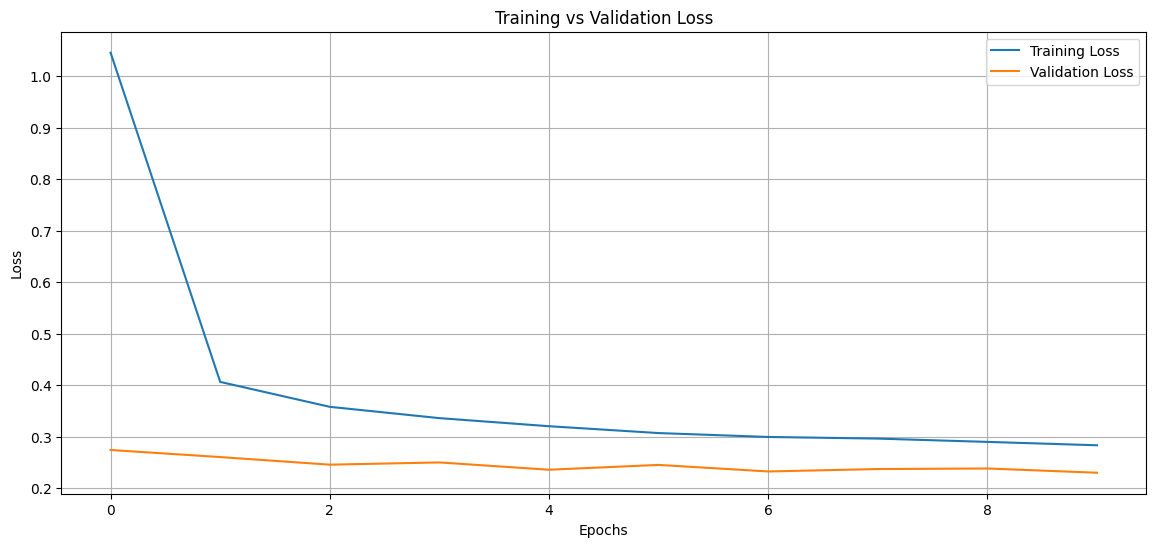

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

**Final Training Testing Validation Graph**

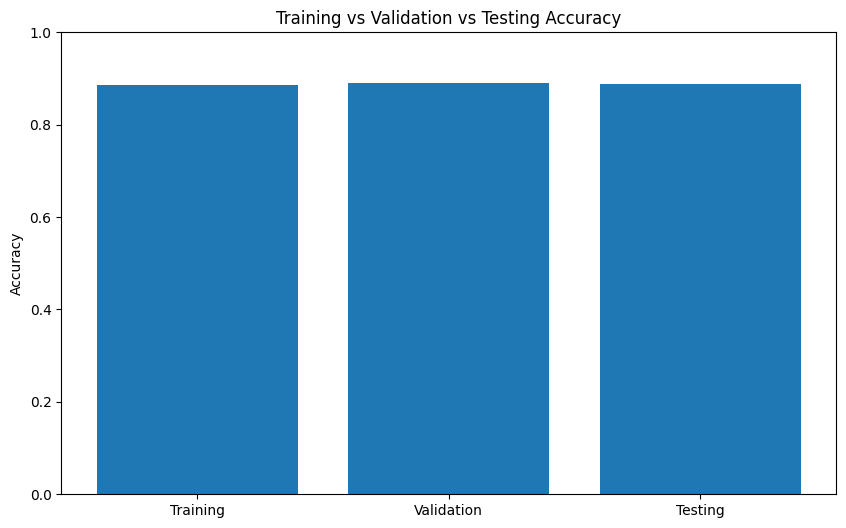

In [ ]:
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])
test_acc = ann_accuracy

stages = [
    'Training',
    'Validation',
    'Testing'
]

values = [
    train_acc,
    val_acc,
    test_acc
]

plt.figure(figsize=(10,6))

plt.bar(stages, values)

plt.ylim(0,1)

plt.title('Training vs Validation vs Testing Accuracy')

plt.ylabel('Accuracy')

plt.show()

**Save ANN Model**

In [ ]:
import os
import pickle

from google.colab import files

# =====================================================
# CREATE MODELS FOLDER
# =====================================================

os.makedirs("models", exist_ok=True)

# =====================================================
# SAVE ANN MODEL
# =====================================================

ann_model.save("models/disease_model.h5")

print("disease_model.h5 saved")

# =====================================================
# SAVE LABEL ENCODER
# =====================================================

with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("label_encoder.pkl saved")

# =====================================================
# SAVE FEATURE COLUMNS
# =====================================================

with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("feature_columns.pkl saved")

# =====================================================
# AUTO DOWNLOAD FILES
# =====================================================

files.download("models/disease_model.h5")
files.download("models/label_encoder.pkl")
files.download("models/feature_columns.pkl")

disease_model.h5 saved
label_encoder.pkl saved
feature_columns.pkl saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>